In [10]:
# In Anaconda Prompt, run "pip install ultralytics --upgrade --force-reinstall --user"
from ultralytics import YOLO

In [11]:
# !pip install opencv-contrib-python
import cv2

In [12]:
import os, shutil # for loading files
import xml.etree.ElementTree as ET

In [13]:
import yaml

In [14]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt
print("NumPy Version:", np.__version__)
print("Scikit-learn Version:", sklearn.__version__)

NumPy Version: 1.26.4
Scikit-learn Version: 1.3.2


In [15]:
from sklearn.model_selection import train_test_split

# View One Image

In [16]:
# https://www.kaggle.com/datasets/andrewmvd/pothole-detection

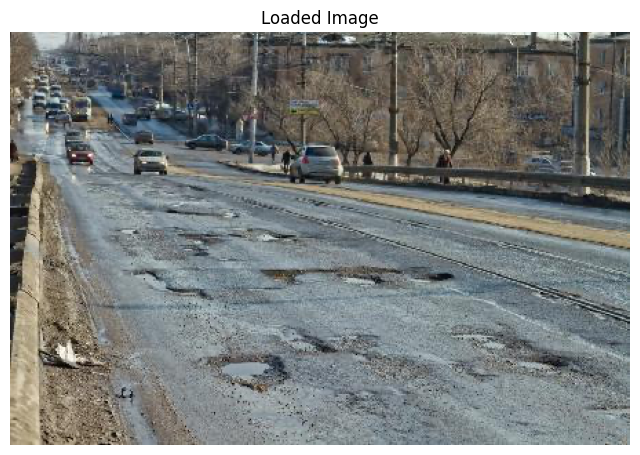

In [17]:
# Load the image
image_path = "Datasets/2/images/potholes0.png"
image = cv2.imread(image_path)

# Convert BGR to RGB (since OpenCV loads images in BGR format)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Loaded Image")
plt.axis("off")  # Hide axes
plt.show()

In [18]:
# Load the XML file
xml_path = "Datasets/2/annotations/potholes0.xml" 
tree = ET.parse(xml_path)
root = tree.getroot()

# Extract bounding boxes from the XML file
bounding_boxes = []
for obj in root.findall("object"):
    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)
    bounding_boxes.append((xmin, ymin, xmax, ymax))

# Display extracted bounding boxes
print(f"{len(bounding_boxes)} Bounding Boxes Extracted:")
for i, bbox in enumerate(bounding_boxes, start=1):
    print(f"Pothole {i}: xmin={bbox[0]}, ymin={bbox[1]}, xmax={bbox[2]}, ymax={bbox[3]}")

12 Bounding Boxes Extracted:
Pothole 1: xmin=141, ymin=233, xmax=203, ymax=262
Pothole 2: xmin=201, ymin=219, xmax=238, ymax=236
Pothole 3: xmin=87, ymin=172, xmax=147, ymax=196
Pothole 4: xmin=181, ymin=171, xmax=212, ymax=185
Pothole 5: xmin=236, ymin=175, xmax=272, ymax=185
Pothole 6: xmin=301, ymin=173, xmax=323, ymax=183
Pothole 7: xmin=231, ymin=169, xmax=284, ymax=177
Pothole 8: xmin=175, ymin=142, xmax=213, ymax=156
Pothole 9: xmin=78, ymin=141, xmax=94, ymax=148
Pothole 10: xmin=123, ymin=145, xmax=152, ymax=157
Pothole 11: xmin=154, ymin=130, xmax=168, ymax=137
Pothole 12: xmin=320, ymin=216, xmax=408, ymax=246


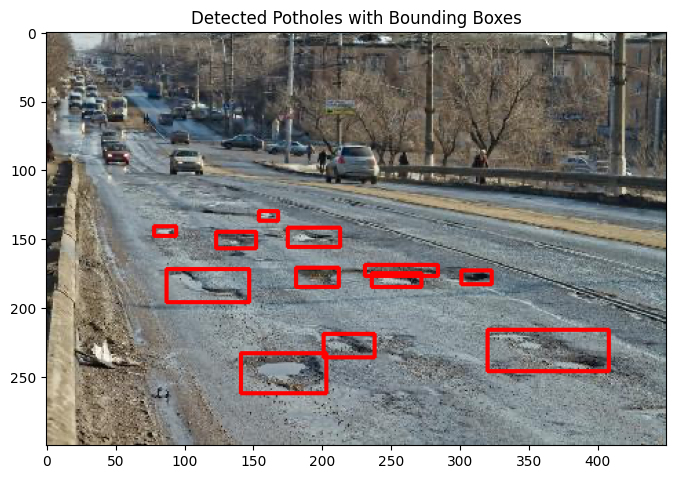

In [19]:
# Draw rectangles on the image
for (xmin, ymin, xmax, ymax) in bounding_boxes:
    cv2.rectangle(image_rgb, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)  # Red rectangle

# Display the image with bounding boxes
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Detected Potholes with Bounding Boxes")
plt.show()

# Convert Annotations to YOLO Format

In [20]:
# We need to convert XML into YOLO format (.txt)
# YOLO format consists of: <class_id> <x_center> <y_center> <width> <height>
# All values are normalized between 0 and 1.

# 1. Parse the XML files to extract bounding box coordinates.
# 2. Convert the coordinates from absolute pixel values to YOLO format (normalized between 0 and 1).
# 3. Create a .txt annotation file for each image with corresponding labels.

In [21]:
def convert_to_yolo(xml_file):
    """Convert a single XML annotation file to YOLO format."""
    # Load and parse the XML file
    tree = ET.parse(os.path.join(xml_folder, xml_file))
    # Get the root element of the XML tree
    root = tree.getroot()

    # Get the image filename from XML (e.g., "potholes0.png")
    image_filename = root.find("filename").text
    # Remove file extension (".png" → "potholes0")
    image_basename = os.path.splitext(image_filename)[0]

    # Get image dimensions
    img_width = int(root.find("size/width").text)
    img_height = int(root.find("size/height").text)

    yolo_annotations = []

    # Process each annotated object in the XML file
    for obj in root.findall("object"):
        class_name = obj.find("name").text  # Get the class name (e.g., "pothole")
        
        if class_name not in class_mapping:
            continue  # Skip objects that are not in the class mapping
    
        class_id = class_mapping[class_name]  # Convert class name to numeric class ID
    
        # Extract bounding box coordinates from XML
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)  # Left boundary of the bounding box
        ymin = int(bbox.find("ymin").text)  # Top boundary of the bounding box
        xmax = int(bbox.find("xmax").text)  # Right boundary of the bounding box
        ymax = int(bbox.find("ymax").text)  # Bottom boundary of the bounding box
    
        # Convert bounding box coordinates to YOLO format (normalized between 0 and 1)
        x_center = (xmin + xmax) / (2 * img_width)  # Normalize center X-coordinate
        y_center = (ymin + ymax) / (2 * img_height)  # Normalize center Y-coordinate
        width = (xmax - xmin) / img_width  # Normalize width of bounding box
        height = (ymax - ymin) / img_height  # Normalize height of bounding box
    
        # Append the YOLO annotation in "<class_id> <x_center> <y_center> <width> <height>" format
        yolo_annotations.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
    
    # Define the output path for the YOLO annotation file
    yolo_txt_path = os.path.join(yolo_labels_folder, f"{image_basename}.txt")
    
    # Save YOLO annotations to a .txt file (one line per object)
    with open(yolo_txt_path, "w") as f:
        f.write("\n".join(yolo_annotations))

In [22]:
# Define dataset paths
image_folder = "Datasets/2/images/"
xml_folder = "Datasets/2/annotations/"
yolo_labels_folder = "Datasets/2/labels/"  # Output YOLO labels

# Ensure output directory exists
os.makedirs(yolo_labels_folder, exist_ok=True)

In [23]:
# Get all XML annotation files
xml_files = []
for f in os.listdir(xml_folder):
    if f.endswith(".xml"):
        xml_files.append(f)

# Class mapping (modify if you have multiple classes)
# Example: {"pothole": 0, "crack": 1}
class_mapping = {"pothole": 0}  

# Convert all XML files
for xml_file in xml_files:
    convert_to_yolo(xml_file)

In [24]:
# Check potholes0.txt (converted to YOLO format)
# Define the path to the converted YOLO annotation file
yolo_txt_path = os.path.join(yolo_labels_folder, "potholes0.txt")

# Open and read the file
with open(yolo_txt_path, "r") as f:
    contents = f.read()

# Print the contents
# YOLO format consists of: <class_id> <x_center> <y_center> <width> <height>
print(contents)

0 0.382222 0.825000 0.137778 0.096667
0 0.487778 0.758333 0.082222 0.056667
0 0.260000 0.613333 0.133333 0.080000
0 0.436667 0.593333 0.068889 0.046667
0 0.564444 0.600000 0.080000 0.033333
0 0.693333 0.593333 0.048889 0.033333
0 0.572222 0.576667 0.117778 0.026667
0 0.431111 0.496667 0.084444 0.046667
0 0.191111 0.481667 0.035556 0.023333
0 0.305556 0.503333 0.064444 0.040000
0 0.357778 0.445000 0.031111 0.023333
0 0.808889 0.770000 0.195556 0.100000


# Load Dataset

In [25]:
# We only need the image and label file (.txt)
# We don't need the xml files because we converted them into YOLO labels (stored in .txt)
image_files = []
labels_files = []

for file in os.listdir(image_folder):
    if file.endswith(".png") or file.endswith(".jpg") or file.endswith(".jpeg"):
        image_files.append(file)

for file in os.listdir(yolo_labels_folder):
    if file.endswith(".txt"):
        labels_files.append(file)

# Print the mapping
print(f"{len(image_files)} image files in total.")
print(f"{len(labels_files)} label files in total.")

665 image files in total.
665 label files in total.


In [26]:
# Create a dictionary to map images to their corresponding label files
image_label_map = {}

for img in image_files:
    # e.g img = "potholes0.png"
    file_type = os.path.splitext(img)[1]  # e.g ".png"
    label_file = img.replace(file_type, ".txt") # e.g label_file = "potholes0.txt"
    image_label_map[img] = label_file # e.g key = potholes0.png, value = potholes0.txt

# Print the first 10 entries
for image, label in list(image_label_map.items())[:10]:
    print(f'{image}: {label}')

potholes0.png: potholes0.txt
potholes1.png: potholes1.txt
potholes10.png: potholes10.txt
potholes100.png: potholes100.txt
potholes101.png: potholes101.txt
potholes102.png: potholes102.txt
potholes103.png: potholes103.txt
potholes104.png: potholes104.txt
potholes105.png: potholes105.txt
potholes106.png: potholes106.txt


# Train Test Validation Split

In [27]:
# Convert dictionary into a list of (image, label) pairs
X = list(image_label_map.keys())  # Image filenames
y = list(image_label_map.values())  # Corresponding label filenames

# Split into training (80%) and temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split temp into validation (10%) and test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert back to dictionaries
train_set = dict(zip(X_train, y_train))
val_set = dict(zip(X_val, y_val))
test_set = dict(zip(X_test, y_test))

# Print dataset sizes
print(f"Training set: {len(train_set)} images")
print(f"Validation set: {len(val_set)} images")
print(f"Test set: {len(test_set)} images")

Training set: 532 images
Validation set: 66 images
Test set: 67 images


In [28]:
'''
YOLO requires us to create subfolders for Train/Test/Validation. We will organize it this way:

📂 Your Project Folder
│── 📜 your_notebook.ipynb  # Your Jupyter Notebook
│── 📂 Dataset
│   │── 📂 2
│   │   │── 📂 images   # Contains all images
│   │   │── 📂 labels   # Contains YOLO annotation .txt files
│   │   │── 📂 train_test_validation_split
│   │   │   │── 📂 train       # Training images + labels
│   │   │   │── 📂 test        # Test images + labels
│   │   │   │── 📂 validation  # Validation images + labels
'''

'\nYOLO requires us to create subfolders for Train/Test/Validation. We will organize it this way:\n\n📂 Your Project Folder\n│── 📜 your_notebook.ipynb  # Your Jupyter Notebook\n│── 📂 Dataset\n│   │── 📂 2\n│   │   │── 📂 images   # Contains all images\n│   │   │── 📂 labels   # Contains YOLO annotation .txt files\n│   │   │── 📂 train_test_validation_split\n│   │   │   │── 📂 train       # Training images + labels\n│   │   │   │── 📂 test        # Test images + labels\n│   │   │   │── 📂 validation  # Validation images + labels\n'

In [29]:
# Define the base dataset path
dataset_base_path = "Datasets/2"

# Define the new split folder
split_folder = os.path.join(dataset_base_path, "train_test_validation_split")

# Define subfolders
subfolders = {
    "train": os.path.join(split_folder, "train"),
    "test": os.path.join(split_folder, "test"),
    "validation": os.path.join(split_folder, "validation"),
}

# Create the split folders if they don't exist
for folder in subfolders.values():
    os.makedirs(folder, exist_ok=True)

In [30]:
# Function to move files
def move_files(file_dict, split_type):
    for image_file, label_file in file_dict.items():
        # Source paths
        image_src = os.path.join(dataset_base_path, "images", image_file)
        label_src = os.path.join(dataset_base_path, "labels", label_file)

        # Destination paths
        image_dst = os.path.join(subfolders[split_type], image_file)
        label_dst = os.path.join(subfolders[split_type], label_file)

        # Copy files over if they exist
        if os.path.exists(image_src):
            shutil.copy2(image_src, image_dst)
        if os.path.exists(label_src):
            shutil.copy2(label_src, label_dst)

In [31]:
# Move the files into the respective folders
move_files(train_set, "train")
move_files(val_set, "validation")
move_files(test_set, "test")

#### YOLO requires us to create a file called data.yaml to record our folder structure

##### Use Absolute Path (to where your notebook is) in the cell below

In [32]:
# Define the content of data.yaml
data_yaml_content = """\
# Dataset configuration for YOLOv8 training

path: C:/Users/qdatp/Documents/CSI4900/CSI 4900 Project/Datasets/2/train_test_validation_split  # Absolute path
train: train  # Path to training images (relative to `path`)
val: validation  # Path to validation images (relative to `path`)
test: test  # Path to test images (relative to `path`)

# Number of classes
nc: 1

# Class names
names: ['pothole']
"""

# Define the file path
yaml_file_path = "Datasets/2/train_test_validation_split/data.yaml"

# Write the content to the file
with open(yaml_file_path, "w") as file:
    file.write(data_yaml_content)

print(f"data.yaml has been created at {yaml_file_path}")

data.yaml has been created at Datasets/2/train_test_validation_split/data.yaml


# YOLO8 Training

In [33]:
# Load the YOLOv8 model
# We can use: "yolov8s.pt", "yolov8m.pt", or "yolov8l.pt". Stands for "Short", "Medium", "Long". 
# Short means highest speed but low accuracy. Long means slow speed but high accuracy
model = YOLO("yolov8s.pt") 

# Train the model
model.train(
    data="Datasets/2/train_test_validation_split/data.yaml",
    epochs=50,  # Adjust as needed
    imgsz=640,  # Image size (default: 640)
    batch=16,  # Batch size (adjust based on GPU memory)
    workers=16,  # Increase this to use more CPU threads (default is 4)
    device="cpu" 
)

Ultralytics 8.3.74  Python-3.12.7 torch-2.6.0+cpu CPU (Intel Core(TM) i7-10750H 2.60GHz)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=Datasets/2/train_test_validation_split/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=16, project=None, name=train17, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

train: Scanning C:\Users\qdatp\Documents\CSI4900\CSI 4900 Project\Datasets\2\train_test_validation_split\train.cache... 532 images, 0 backgrounds, 0 corrupt: 100%|██████████| 532/532 [00:00<?, ?it/s]
val: Scanning C:\Users\qdatp\Documents\CSI4900\CSI 4900 Project\Datasets\2\train_test_validation_split\validation.cache... 66 images, 0 backgrounds, 0 corrupt: 100%|██████████| 66/66 [00:00<?, ?it/s]


Plotting labels to runs\detect\train17\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\train17
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50         0G       1.56      2.424      1.486         17        640: 100%|██████████| 34/34 [05:42<00:00, 10.07s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:14<00:00,  4.96s/it]

                   all         66        197      0.393      0.264      0.276       0.14


...

                   all         66        197      0.719       0.65      0.718       0.45



50 epochs completed in 5.114 hours.
Optimizer stripped from runs\detect\train17\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\train17\weights\best.pt, 22.5MB

Validating runs\detect\train17\weights\best.pt...
Ultralytics 8.3.74  Python-3.12.7 torch-2.6.0+cpu CPU (Intel Core(TM) i7-10750H 2.60GHz)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:12<00:00,  4.01s/it]


                   all         66        197      0.707      0.675      0.715      0.458
Speed: 2.2ms preprocess, 166.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs\detect\train17


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026079387020>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

# Results

In [ ]:
# Results of training seen in C:\Users\qdatp\Documents\CSI4900\CSI 4900 Project\runs\detect\train17